In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

Matplotlib is building the font cache; this may take a moment.


In [2]:
PROJECT_ROOT = Path("..")

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Files in raw data folder:")
for file in RAW_DATA_DIR.glob("*"):
    print(file.name)

Files in raw data folder:
diabetes_binary_health_indicators_BRFSS2015.csv


In [3]:
file_path = RAW_DATA_DIR / "diabetes_binary_health_indicators_BRFSS2015.csv"

df = pd.read_csv(file_path)

df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [4]:
print("Dataset shape:", df.shape)

print("\nColumns:")
df.columns.tolist()

Dataset shape: (253680, 22)

Columns:


['Diabetes_binary',
 'HighBP',
 'HighChol',
 'CholCheck',
 'BMI',
 'Smoker',
 'Stroke',
 'HeartDiseaseorAttack',
 'PhysActivity',
 'Fruits',
 'Veggies',
 'HvyAlcoholConsump',
 'AnyHealthcare',
 'NoDocbcCost',
 'GenHlth',
 'MentHlth',
 'PhysHlth',
 'DiffWalk',
 'Sex',
 'Age',
 'Education',
 'Income']

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [7]:
missing_report = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": df.isnull().mean() * 100
}).sort_values(by="missing_count", ascending=False)

missing_report

,missing_count,missing_percentage
Diabetes_binary,0,0.0
HighBP,0,0.0
Education,0,0.0
Age,0,0.0
Sex,0,0.0
DiffWalk,0,0.0
PhysHlth,0,0.0
MentHlth,0,0.0
GenHlth,0,0.0
NoDocbcCost,0,0.0


In [8]:
missing_report.to_csv(REPORTS_DIR / "day1_missing_values_report.csv", index=False)

In [9]:
duplicate_count = df.duplicated().sum()
duplicate_percentage = duplicate_count / len(df) * 100

print("Duplicate rows:", duplicate_count)
print("Duplicate percentage:", duplicate_percentage)

Duplicate rows: 24206
Duplicate percentage: 9.541942604856512


In [10]:
TARGET_COL = "Diabetes_binary"

target_counts = df[TARGET_COL].value_counts().sort_index()
target_percentages = df[TARGET_COL].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percentages
})

target_summary

,count,percentage
Diabetes_binary,,
0.0,218334,86.066698
1.0,35346,13.933302


In [11]:
target_summary.to_csv(REPORTS_DIR / "day1_target_distribution.csv")

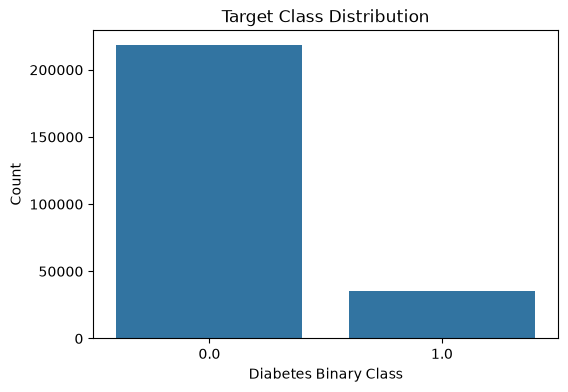

In [12]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=TARGET_COL)
plt.title("Target Class Distribution")
plt.xlabel("Diabetes Binary Class")
plt.ylabel("Count")
plt.show()

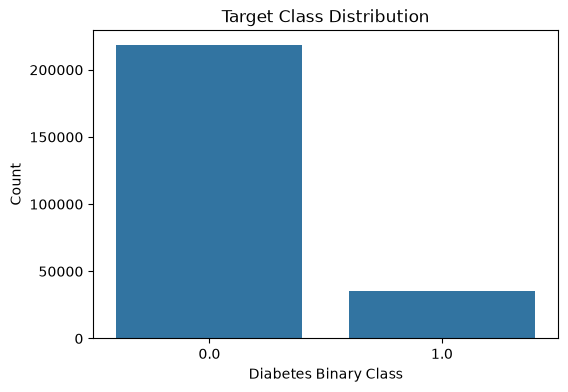

In [13]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=TARGET_COL)
plt.title("Target Class Distribution")
plt.xlabel("Diabetes Binary Class")
plt.ylabel("Count")
plt.savefig(FIGURES_DIR / "target_distribution.png", bbox_inches="tight", dpi=300)
plt.show()

In [15]:
feature_summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.values,
    "unique_values": df.nunique().values,
    "missing_values": df.isnull().sum().values
})

feature_summary.sort_values(by="unique_values")
feature_summary.to_csv(REPORTS_DIR / "day1_feature_summary.csv", index=False)

In [16]:
stat_summary = df.describe().T
stat_summary

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,253680.0,0.139333,0.346294,0.0,0.0,0.0,0.0,1.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


In [17]:
stat_summary.to_csv(REPORTS_DIR / "day1_statistical_summary.csv")

In [18]:
binary_cols = [col for col in df.columns if df[col].nunique() == 2]
multi_category_cols = [col for col in df.columns if 2 < df[col].nunique() <= 15]
continuous_cols = [col for col in df.columns if df[col].nunique() > 15]

print("Binary columns:", binary_cols)
print("\nMulti-category / ordinal columns:", multi_category_cols)
print("\nContinuous columns:", continuous_cols)

Binary columns: ['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']

Multi-category / ordinal columns: ['GenHlth', 'Age', 'Education', 'Income']

Continuous columns: ['BMI', 'MentHlth', 'PhysHlth']


In [19]:
correlations = df.corr(numeric_only=True)[TARGET_COL].sort_values(ascending=False)

correlations

Diabetes_binary         1.000000
GenHlth                 0.293569
HighBP                  0.263129
DiffWalk                0.218344
BMI                     0.216843
HighChol                0.200276
Age                     0.177442
HeartDiseaseorAttack    0.177282
PhysHlth                0.171337
Stroke                  0.105816
MentHlth                0.069315
CholCheck               0.064761
Smoker                  0.060789
NoDocbcCost             0.031433
Sex                     0.031430
AnyHealthcare           0.016255
Fruits                 -0.040779
Veggies                -0.056584
HvyAlcoholConsump      -0.057056
PhysActivity           -0.118133
Education              -0.124456
Income                 -0.163919
Name: Diabetes_binary, dtype: float64

In [20]:
top_10_corr = correlations.drop(TARGET_COL).abs().sort_values(ascending=False).head(10)
top_10_corr

GenHlth                 0.293569
HighBP                  0.263129
DiffWalk                0.218344
BMI                     0.216843
HighChol                0.200276
Age                     0.177442
HeartDiseaseorAttack    0.177282
PhysHlth                0.171337
Income                  0.163919
Education               0.124456
Name: Diabetes_binary, dtype: float64

In [21]:
correlations.to_csv(REPORTS_DIR / "day1_target_correlations.csv")

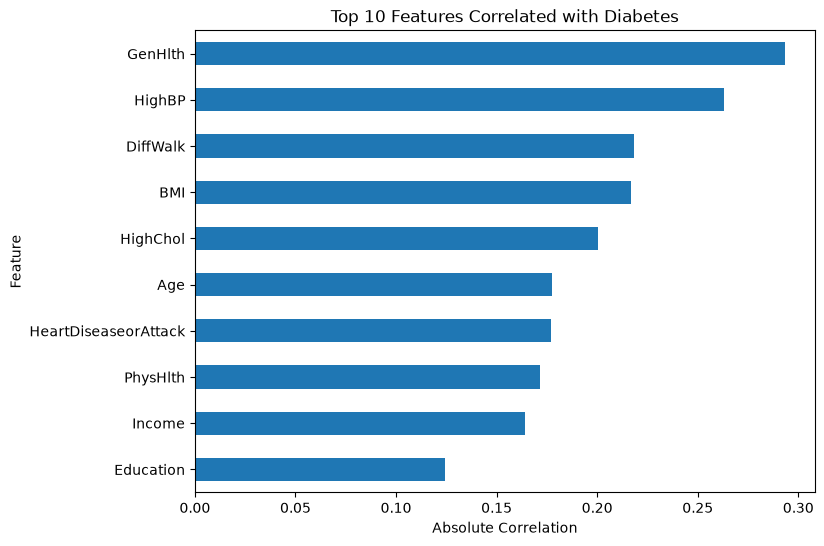

In [22]:
plt.figure(figsize=(8, 6))
top_10_corr.sort_values().plot(kind="barh")
plt.title("Top 10 Features Correlated with Diabetes")
plt.xlabel("Absolute Correlation")
plt.ylabel("Feature")
plt.savefig(FIGURES_DIR / "top_10_target_correlations.png", bbox_inches="tight", dpi=300)
plt.show()

In [27]:
Basic_summary = {
    "dataset_shape": df.shape,
    "total_rows": df.shape[0],
    "total_columns": df.shape[1],
    "target_column": TARGET_COL,
    "missing_values_total": int(df.isnull().sum().sum()),
    "duplicate_rows": int(df.duplicated().sum()),
    "target_distribution": df[TARGET_COL].value_counts().to_dict(),
    "binary_columns_count": len(binary_cols),
    "multi_category_columns_count": len(multi_category_cols),
    "continuous_columns_count": len(continuous_cols)
}

Basic_summary

{'dataset_shape': (253680, 22),
 'total_rows': 253680,
 'total_columns': 22,
 'target_column': 'Diabetes_binary',
 'missing_values_total': 0,
 'duplicate_rows': 24206,
 'target_distribution': {0.0: 218334, 1.0: 35346},
 'binary_columns_count': 15,
 'multi_category_columns_count': 4,
 'continuous_columns_count': 3}

In [28]:
with open(REPORTS_DIR / "day1_summary.txt", "w") as f:
    f.write("Day 1: Data Validation and Problem Framing Summary\n")
    f.write("=" * 60 + "\n\n")
    
    for key, value in Basic_summary.items():
        f.write(f"{key}: {value}\n")

In [29]:
df.to_csv(PROCESSED_DATA_DIR / "diabetes_Basic_validated.csv", index=False)